In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

### Dataset Importing

In [8]:
# Load Data
coursera_df = pd.read_csv('Coursera.csv')
edx_df = pd.read_csv('edx.csv')
skillshare_df = pd.read_csv('skillshare.csv')
udemy_df = pd.read_csv('Udemy.csv')

### Summary Table

In [9]:
datasets = {
    "Coursera": coursera_df,
    "edX": edx_df,
    "Skillshare": skillshare_df,
    "Udemy": udemy_df
}

# Create summary table with duplicate check
summary_rows = []

for name, df in datasets.items():
    # Count duplicates based on all columns
    duplicate_count = df.duplicated().sum()
    
    row = {
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Missing %": round(df.isnull().sum().sum() / (df.shape[0]*df.shape[1]) * 100, 2),
        "Duplicate Rows": duplicate_count,
        "Numeric Columns": df.select_dtypes(include='number').columns.tolist(),
        "Object Columns": df.select_dtypes(include='object').columns.tolist(),
        "Sample Min/Max (numeric)": df.select_dtypes(include='number')
                                    .agg(['min','max'])
                                    .to_dict()    
                                    if not df.select_dtypes(include='number').empty 
                                    else {}
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df)


      Dataset   Rows  Columns  Missing Values  Missing %  Duplicate Rows  \
0    Coursera   1139        9             524       5.11              10   
1         edX    816       10             980      12.01              26   
2  Skillshare  14250        5               0       0.00              14   
3       Udemy  26256        8             372       0.18             410   

         Numeric Columns                                     Object Columns  \
0               [rating]  [partner, course, skills, reviewcount, level, ...   
1                     []  [title, link, institution, subject, level, pre...   
2                     []      [title, link, duration, instructor, students]   
3  [rating, reviewcount]  [title, description, instructor, duration, lec...   

                            Sample Min/Max (numeric)  
0               {'rating': {'min': 2.8, 'max': 5.0}}  
1                                                 {}  
2                                                 {}  
3  

In [23]:
print(coursera_df.head())
print()
print(coursera_df.info())

  partner                                 course  \
0  Google                   Google Cybersecurity   
1  Google                  Google Data Analytics   
2  Google             Google Project Management:   
3  Google  Google Digital Marketing & E-commerce   
4  Google                      Google IT Support   

                                              skills  rating reviewcount  \
0  {" Network Security"," Python Programming"," L...     4.8       16.4k   
1  {" Data Analysis"," R Programming"," SQL"," Bu...     4.8      133.4k   
2  {" Project Management"," Strategy and Operatio...     4.8       97.3k   
3  {" Digital Marketing"," Marketing"," Marketing...     4.8       21.4k   
4  {" Computer Networking"," Network Architecture...     4.8      181.4k   

       level             certificatetype       duration  crediteligibility  
0  Beginner    Professional Certificate    3 - 6 Months              False  
1  Beginner    Professional Certificate    3 - 6 Months               True  

In [24]:
print(edx_df.head())
print()
print(edx_df.info())

                                               title  \
0                                How to Learn Online   
1                           The Science of Happiness   
2                 Remote Work Revolutionfor Everyone   
3             CS50's Introduction toComputer Science   
4  Data Visualization andBuilding Dashboards with...   

                                                link  \
0  https://www.edx.org/learn/how-to-learn/edx-how...   
1  https://www.edx.org/learn/happiness/university...   
2  https://www.edx.org/learn/remote-work/harvard-...   
3  https://www.edx.org/learn/computer-science/har...   
4  https://www.edx.org/learn/data-visualization/i...   

                          institution                       subject  \
0                                 edX  Education & Teacher Training   
1  University of California, Berkeley               Social Sciences   
2                  Harvard University         Business & Management   
3                  Harvard University     

In [25]:
print(skillshare_df.head())
print()
print(skillshare_df.info())

                                               title  \
0                   Fundamentals of DSLR Photography   
1  Video Editing with Adobe Premiere Pro for Begi...   
2  Productivity Masterclass - Principles and Tool...   
3    Adobe Photoshop CC – Essentials Training Course   
4  Mastering Productivity: Create a Custom System...   

                                                link duration  \
0  https://www.skillshare.com/en/classes/Fundamen...   1h 19m   
1  https://www.skillshare.com/en/classes/Video-Ed...   3h 21m   
2  https://www.skillshare.com/en/classes/Producti...   1h 55m   
3  https://www.skillshare.com/en/classes/Adobe-Ph...   9h 56m   
4  https://www.skillshare.com/en/classes/Masterin...    1h 5m   

                          instructor          students  
0  Photo Essentials x Justin Bridges  133,422 students  
1                     Jordy Vandeput  126,674 students  
2                         Ali Abdaal  109,681 students  
3                       Daniel Scott   98,74

In [26]:
print(udemy_df.head())
print()
print(udemy_df.info())

                                               title  \
0  The Complete Python Bootcamp From Zero to Hero...   
1         The Complete 2023 Web Development Bootcamp   
2                    The Web Developer Bootcamp 2023   
3  100 Days of Code: The Complete Python Pro Boot...   
4  React - The Complete Guide 2023 (incl. React R...   

                                         description  \
0  Learn Python like a Professional  Start from t...   
1  Become a Full-Stack Web Developer with just ON...   
2  10 Hours of React just added. Become a Develop...   
3  Master Python by building 100 projects in 100 ...   
4  Dive in and learn React.js from scratch! Learn...   

                                          instructor  rating  reviewcount  \
0                                      Jose Portilla     4.6       486391   
1                                      Dr. Angela Yu     4.7       338555   
2                                        Colt Steele     4.7       266527   
3                 

### Column Name Standardization

In [10]:
# Column Name Standardization
df1 = coursera_df.rename(columns={'course': 'Title', 
                                  'rating': 'Rating', 
                                  'duration': 'Duration'})
df2 = edx_df.rename(columns={'title': 'Title'})
df3 = skillshare_df.rename(columns={'title': 'Title', 
                                  'duration': 'Duration'})
df4 = udemy_df.rename(columns={'title': 'Title', 
                               'rating': 'Rating', 
                                'duration': 'Duration'})

In [11]:
# --- Helper Functions for Cleaning and Transformation---
def clean_coursera_skills(x):
    if pd.isna(x): return ""
    # Remove json artifacts: {" and "}
    return x.replace('{"', '').replace('"}', '').replace('"', '').replace(',', ', ')

# Function to infer title from URL
def infer_title_from_url(row):
    if pd.isna(row['Title']) and isinstance(row['link'], str):
        # Extract the last part of the URL: ".../course-name"
        slug = row['link'].strip('/').split('/')[-1]
        # Replace hyphens with spaces and capitalize before returning
        return slug.replace('-', ' ').title()
    return row['Title']

### Column Standardization and Transformation

In [ ]:
# Infer edX Title from Link
df2['Title'] = df2.apply(infer_title_from_url, axis=1)

# Create Platform column
df1['Platform'] = 'Coursera'
df2['Platform'] = 'edX'
df3['Platform'] = 'Skillshare'
df4['Platform'] = 'Udemy'

# Create Skill_Text column
df1['Skill_Text'] = df1['skills'].apply(clean_coursera_skills)
df2['Skill_Text'] = df2['associatedskills'].fillna(df2['Title'])
df3['Skill_Text'] = df3['Title']
df4['Skill_Text'] = df4['description'].fillna(df4['Title'])

# Create Rating column for edX and SkillShare
df2['Rating'] = np.nan
df3['Rating'] = np.nan

# Create Duration Column for edX
df2['Duration'] = np.nan

### Combine all the datasets into Unified Course Dataset

In [13]:
# --- Concatenate ---
df1 = df1[['Title', 'Platform', 'Skill_Text', 'Rating', 'Duration']]
df2 = df2[['Title', 'Platform', 'Skill_Text', 'Rating', 'Duration']]
df3 = df3[['Title', 'Platform', 'Skill_Text', 'Rating', 'Duration']]
df4 = df4[['Title', 'Platform', 'Skill_Text', 'Rating', 'Duration']]
unified_df = pd.concat([df1, df2, df3, df4], ignore_index=True)
print("Unified dataset shape: ", unified_df.shape)

# Table of missing counts and percentages
print("\nMissing Data Report of Unified Dataset:")
missing_stats = pd.concat([unified_df.isnull().sum(), 
                           (unified_df.isnull().sum() / len(unified_df)) * 100], 
                           axis=1, 
                           keys=['Count', 'Percentage'])
print(missing_stats)

Unified dataset shape:  (42461, 5)

Missing Data Report of Unified Dataset:
            Count  Percentage
Title           0    0.000000
Platform        0    0.000000
Skill_Text      0    0.000000
Rating      15212   35.825817
Duration      839    1.975931


## Missing Data Imputation

In [ ]:
# --- Missing Value Imputation ---
# Fill missing ratings with mean by platform
unified_df['Rating'] = unified_df.groupby('Platform')['Rating']\
    .transform(lambda x: x.fillna(x.mean()))

# Global mean fallback (for platforms with no ratings)
global_mean = unified_df['Rating'].mean().round(2)
print("Global Mean = ", global_mean)
unified_df['Rating'] = unified_df['Rating'].fillna(global_mean)

# Fill missing durations with 'unknown'
unified_df['Duration'] = unified_df['Duration'].fillna('unknown')

Global Mean =  4.33


In [28]:
# Validate dataset before aligning with standardized O*NET wordings
print(unified_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42461 entries, 0 to 42460
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Title       42461 non-null  object 
 1   Platform    42461 non-null  object 
 2   Skill_Text  42461 non-null  object 
 3   Rating      42461 non-null  float64
 4   Duration    42461 non-null  object 
dtypes: float64(1), object(4)
memory usage: 1.6+ MB
None


In [18]:
unified_df.to_csv("unified_df_course.csv", index=False)

## Semantic Ontology Aligner

In [ ]:
import pandas as pd
import numpy as np
import re
import os
import torch
import pickle
from sentence_transformers import SentenceTransformer, util
from sklearn.feature_extraction.text import CountVectorizer
from tqdm import tqdm

# CONFIGURATION & FILE PATHS
OUTPUT_FILE = 'unified_df_course_aligned.csv'
RAW_COURSE_FILE = 'unified_df_course.csv'
ONET_ONTOLOGY_FILE = 'master_vocab.pkl'

# Set the similarity threshold
SIMILARITY_THRESHOLD = 0.72

# Save progress to disk every X resumes
CHECKPOINT_INTERVAL = 1000

# INITIALIZE MODEL & DEVICE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Initializing S-BERT on device: {device}")
aligner = SentenceTransformer('all-mpnet-base-v2').to(device)

# HELPER FUNCTIONS
def preserve_tech_syntax(text: str) -> str:
    """Cleans text while preserving vital tech syntax like C++, C#, .NET."""
    if not isinstance(text, str): return ""
    return ' '.join(re.sub(r'[^a-z0-9\+\#\.]', ' ', str(text).lower()).split())

def extract_ngrams(text: str, ngram_range=(1,3)) -> list:
    """Extracts 1 to 3-word chunks from a single resume to compare against O*NET."""
    vectorizer = CountVectorizer(ngram_range=ngram_range, 
                                 stop_words='english',
                                token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*')
    try:
        vectorizer.fit([text])
        return vectorizer.get_feature_names_out().tolist()
    except ValueError:
        return []

sample = "C C++ C# .NET SQL Python Node.js ASP.NET"
print(extract_ngrams(sample))

# LOAD DATA & PREPARE ONTOLOGY
print("\nLoading dataset and checking for checkpoints...")

# --- CHECKPOINT RESUMPTION LOGIC ---
if os.path.exists(OUTPUT_FILE):
    print(f"⚠️ Found existing checkpoint file '{OUTPUT_FILE}'. Resuming progress...")
    # keep_default_na=False ensures empty strings "" aren't read as NaN
    df_raw = pd.read_csv(OUTPUT_FILE, keep_default_na=False)
else:
    print(f"Starting fresh from '{RAW_COURSE_FILE}'...")
    df_raw = pd.read_csv(RAW_COURSE_FILE)
    # Initialize the target column with a specific placeholder
    df_raw['Aligned_Text'] = "__UNPROCESSED__"

# Check if target column exists
if 'Resume_Text' not in df_raw.columns:
    raise ValueError(f"Column 'Resume_Text' not found. Please rename your text column.")

# Load Ontology
with open(ONET_ONTOLOGY_FILE, "rb") as f:
    master_vocab = pickle.load(f)
print(f"Extracted {len(master_vocab)} unique O*NET competencies.")

print("Precomputing O*NET Ontology Embeddings...")
ontology_embs = aligner.encode(master_vocab, convert_to_tensor=True, device=device)

# THE DETERMINISTIC ALIGNER CORE
def align_resume_to_ontology(messy_text: str) -> str:
    """Maps messy resume text to official O*NET dictionary using S-BERT."""
    cleaned = preserve_tech_syntax(messy_text)
    chunks = extract_ngrams(cleaned)

    if not chunks:
        return ""

    chunk_embs = aligner.encode(chunks, convert_to_tensor=True, device=device)
    cosine_scores = util.cos_sim(chunk_embs, ontology_embs)

    aligned = set()
    max_scores, max_indices = torch.max(cosine_scores, dim=1)

    for i, score in enumerate(max_scores):
        if score.item() >= SIMILARITY_THRESHOLD:
            aligned.add(master_vocab[max_indices[i].item()])

    return ' '.join(sorted(aligned))

# EXECUTION WITH CHECKPOINTS
# Identify indices that have not been processed yet
unprocessed_mask = df_raw['Aligned_Text'] == "__UNPROCESSED__"
unprocessed_indices = df_raw[unprocessed_mask].index

print(f"\n--- EXECUTION STATUS ---")
print(f"Total rows in dataset: {len(df_raw)}")
print(f"Rows already processed: {len(df_raw) - len(unprocessed_indices)}")
print(f"Rows remaining: {len(unprocessed_indices)}")

if len(unprocessed_indices) > 0:
    print("\nStarting Semantic Alignment Pipeline...")

    # Initialize progress bar for the remaining rows
    pbar = tqdm(total=len(unprocessed_indices), desc="Aligning Resumes", unit="resume")

    for count, idx in enumerate(unprocessed_indices, start=1):
        resume_text = df_raw.at[idx, 'Resume_Text']
        # resume_text = df_raw.at[idx, 'Skill_Text']

        # Run alignment and update dataframe in-place
        df_raw.at[idx, 'Aligned_Text'] = align_resume_to_ontology(resume_text)
        pbar.update(1)

        # Trigger checkpoint save
        if count % CHECKPOINT_INTERVAL == 0:
            df_raw.to_csv(OUTPUT_FILE, index=False)

    pbar.close()

    # Final guaranteed save after exiting loop
    df_raw.to_csv(OUTPUT_FILE, index=False)
    print(f"\nAlignment complete! Final dataset successfully saved to '{OUTPUT_FILE}'.")
else:
    print(f"\nDataset is already 100% aligned in '{OUTPUT_FILE}'. No action needed.")

Initializing S-BERT on device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Loading dataset and checking for checkpoints...
Starting fresh from '/content/drive/MyDrive/Colab Notebooks/unified_df_course.csv'...
Extracted 366 unique O*NET competencies.
Precomputing O*NET Ontology Embeddings...

--- EXECUTION STATUS ---
Total rows in dataset: 42461
Rows already processed: 0
Rows remaining: 42461

Starting Semantic Alignment Pipeline...


Aligning Resumes: 100%|██████████| 42461/42461 [14:52<00:00, 47.55resume/s]



✅ Alignment complete! Final dataset successfully saved to '/content/drive/MyDrive/Colab Notebooks/unified_df_course_aligned.csv'.


In [27]:
import pandas as pd
unified_df_aligned = pd.read_csv('unified_df_course_aligned.csv')
unified_df_aligned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42461 entries, 0 to 42460
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         42461 non-null  object 
 1   Platform      42461 non-null  object 
 2   Skill_Text    42391 non-null  object 
 3   Rating        42461 non-null  float64
 4   Duration      42461 non-null  object 
 5   Aligned_Text  22946 non-null  object 
dtypes: float64(1), object(5)
memory usage: 1.9+ MB


### Aligned_Text Cleaning

In [29]:
# --- Check, Inspect, and Handle Empty Aligned_Text ---
print("Total rows before removing invalid Aligned_Text: ", unified_df_aligned.shape[0])
# Create mask for invalid Aligned_Text (NaN OR empty/whitespace)
invalid_mask = (
    unified_df_aligned['Aligned_Text'].isna() |
    (unified_df_aligned['Aligned_Text'].astype(str).str.strip() == "")
)

# Counts
nan_count = unified_df_aligned['Aligned_Text'].isna().sum()
empty_count = (unified_df_aligned['Aligned_Text'].astype(str).str.strip() == "").sum()
total_invalid = invalid_mask.sum()

print(f"NaN Aligned_Text: {nan_count}")
print(f"Empty/Whitespace Aligned_Text: {empty_count}")
print(f"Total invalid Aligned_Text rows: {total_invalid}")

# --- Remove invalid rows (only if you're sure) ---
unified_df_aligned = unified_df_aligned[~invalid_mask]
print("Total rows after removing invalid Aligned_Text: ", unified_df_aligned.shape[0])

Total rows before removing invalid Aligned_Text:  42461
NaN Aligned_Text: 19515
Empty/Whitespace Aligned_Text: 0
Total invalid Aligned_Text rows: 19515
Total rows after removing invalid Aligned_Text:  22946


In [30]:
# --- Remove Duplicate Rows ---
print("Total rows before removing duplicate rows: ", unified_df_aligned.shape[0])

# Count duplicates before removal
duplicates_before = unified_df_aligned.duplicated(subset=['Title', 'Skill_Text']).sum()
print(f"Number of duplicate rows before removal: {duplicates_before}")

# Drop duplicates based on relevant columns
unified_df_aligned.drop_duplicates(subset=['Title', 'Skill_Text'], inplace=True)

# Count duplicates after removal
duplicates_after = unified_df_aligned.duplicated(subset=['Title', 'Skill_Text']).sum()
print(f"Number of duplicate rows after removal: {duplicates_after}")
print("Total rows after removing duplicate rows: ", unified_df_aligned.shape[0])

Total rows before removing duplicate rows:  22946
Number of duplicate rows before removal: 295
Number of duplicate rows after removal: 0
Total rows after removing duplicate rows:  22651


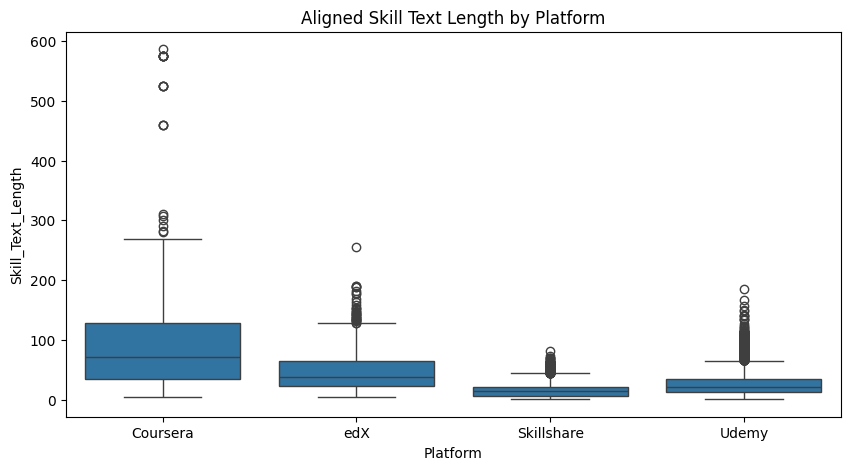

In [45]:
# Create Skill_Text_Length feature for outlier detection
unified_df_aligned['Skill_Text_Length'] = unified_df_aligned['Aligned_Text'].astype(str).apply(len)

# Platform comparison of text
plt.figure(figsize=(10,5))
sns.boxplot(data=unified_df_aligned, x='Platform', y='Skill_Text_Length')
plt.title('Aligned Skill Text Length by Platform')
plt.show()

In [57]:
# Remove Skill_Text_Length column before saving
unified_online_course_df = unified_df_aligned.drop(
    ['Skill_Text_Length', 'Skill_Text'], axis=1
)

# Save
unified_online_course_df.to_csv('Unified_Course_Dataset.csv', index=False)

## Data Understanding

In [58]:
print("Dataset shape:", unified_online_course_df.shape)
print(unified_online_course_df.head())
print()
print(unified_online_course_df.info())

Dataset shape: (22651, 5)
                                   Title  Platform  Rating       Duration  \
0                   Google Cybersecurity  Coursera     4.8   3 - 6 Months   
1                  Google Data Analytics  Coursera     4.8   3 - 6 Months   
2             Google Project Management:  Coursera     4.8   3 - 6 Months   
3  Google Digital Marketing & E-commerce  Coursera     4.8   3 - 6 Months   
4                      Google IT Support  Coursera     4.8   3 - 6 Months   

                                        Aligned_Text  
0  administration and management building and con...  
1  administration and management business softwar...  
2  administration and management engineering and ...  
3  administration and management communications a...  
4  administration and management building and con...  

<class 'pandas.core.frame.DataFrame'>
Index: 22651 entries, 0 to 42457
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        -------------- 

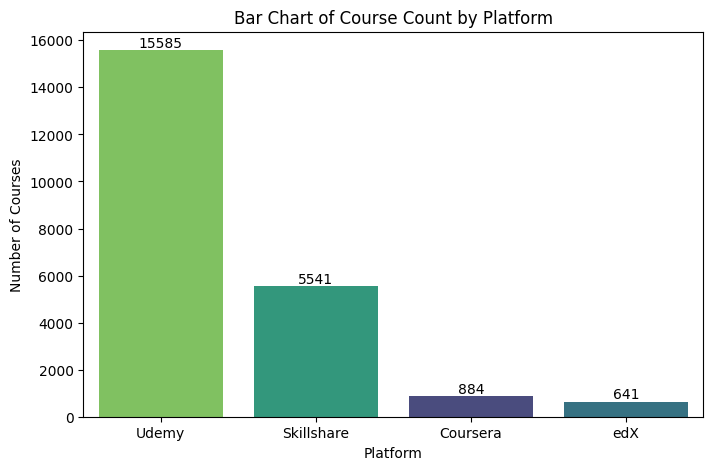

In [60]:
# Course Count by Platform
plt.figure(figsize=(8, 5))
chart = sns.countplot(data=unified_online_course_df, 
              x='Platform', 
              order=unified_online_course_df['Platform'].value_counts().index, 
              palette='viridis',
              hue='Platform')
plt.title('Bar Chart of Course Count by Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Courses')

# Add value labels on top of each bar
for container in chart.containers:
    chart.bar_label(container, fmt='%d')

plt.show()

In [61]:
print("\nDescriptive Statistics (Numeric Variables):")
unified_online_course_df.describe()


Descriptive Statistics (Numeric Variables):


,Rating
count,22651.000000
mean,4.329167
std,0.347310
min,1.000000
25%,4.300000
50%,4.330000
75%,4.500000
max,5.000000


Text(0, 0.5, 'Frequency')

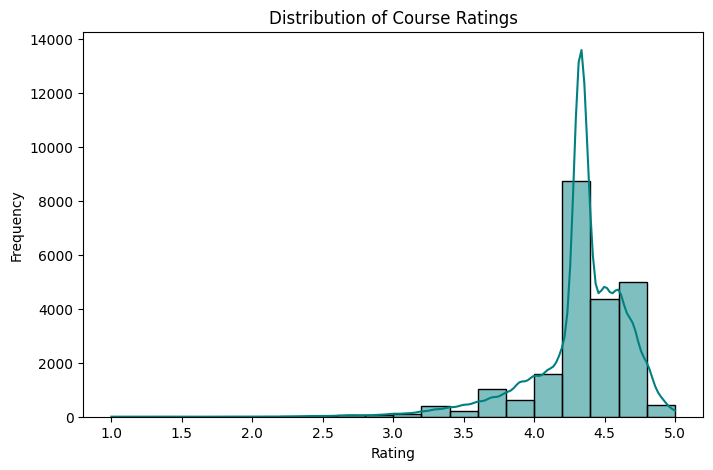

In [62]:
# Distribution of Course Ratings
plt.figure(figsize=(8, 5))
sns.histplot(unified_online_course_df['Rating'], bins=20, kde=True, color='teal')
plt.title('Distribution of Course Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

(3.0, 5.2)

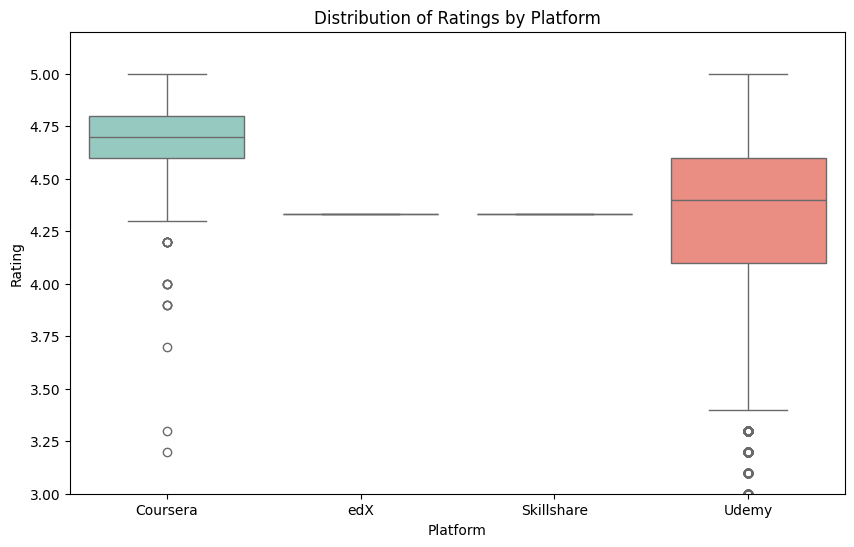

In [63]:
# Rating vs Platform (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=unified_online_course_df, 
            x='Platform', 
            y='Rating', 
            palette='Set3',
            hue= 'Platform')
plt.title('Distribution of Ratings by Platform')
plt.ylim(3.0, 5.2) # Zoom in on the relevant range

<Figure size 1000x600 with 0 Axes>

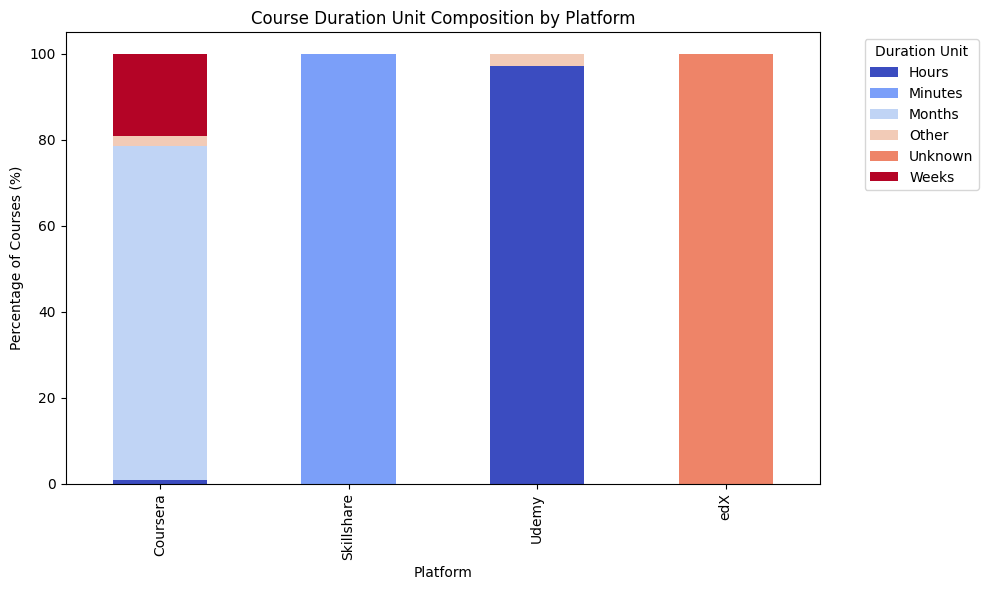

In [64]:
# Duration Unit vs Platform Heatmap/Stack
def get_unit(text):
    text = str(text).lower()
    if 'month' in text: return 'Months'
    if 'week' in text: return 'Weeks'
    if 'unknown' in text: return 'Unknown'
    if 'hour' in text: return 'Hours'
    if 'minute' in text or 'm' in text[-2:]: return 'Minutes'
    return 'Other'

unified_online_course_df['Duration_Unit'] = unified_online_course_df['Duration'].apply(get_unit)
ct = pd.crosstab(unified_online_course_df['Platform'], unified_online_course_df['Duration_Unit'], normalize='index') * 100

plt.figure(figsize=(10, 6))
ct.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(10, 6))
plt.title('Course Duration Unit Composition by Platform')
plt.ylabel('Percentage of Courses (%)')
plt.xlabel('Platform')
plt.legend(title='Duration Unit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

In [65]:
# Create Skill_Text_Length feature for outlier detection
unified_online_course_df['Skill_Text_Length'] = unified_online_course_df['Aligned_Text'].astype(str).apply(len)

In [66]:
# --- 1. Feature Engineering: Transform Duration (The tricky part) ---
def parse_duration_to_hours(duration_str):
    if pd.isna(duration_str) or duration_str == 'unknown':
        return None
    
    text = str(duration_str).lower()
    
    # Extract all numbers (integers or decimals) from the string
    numbers = [float(n) for n in re.findall(r"(\d+(?:\.\d+)?)", text)]
    
    if not numbers:
        return None
    
    # Calculate the average if it's a range (e.g., "3-6 months" -> 4.5)
    value = np.mean(numbers)
    
    # Apply multipliers to convert everything to "Hours" (Approximations)
    # Assumptions: 1 Month = ~16 study hours (4 weeks * 4 hrs/week)
    #              1 Week = ~4 study hours
    if 'minute' in text:
        return value / 60
    elif 'hour' in text:
        return value
    elif 'week' in text:
        return value * 4
    elif 'month' in text or 'mes' in text: # 'mes' handles Spanish 'meses'
        return value * 16
    elif 'year' in text:
        return value * 16 * 12
    else:
        return None # If unit isn't recognized

# Apply the transformation
unified_online_course_df['Estimated_Hours'] = unified_online_course_df['Duration'].apply(parse_duration_to_hours)

# Calculate Title Length (character count)
unified_online_course_df['Title_Length'] = unified_online_course_df['Title'].astype(str).apply(len)

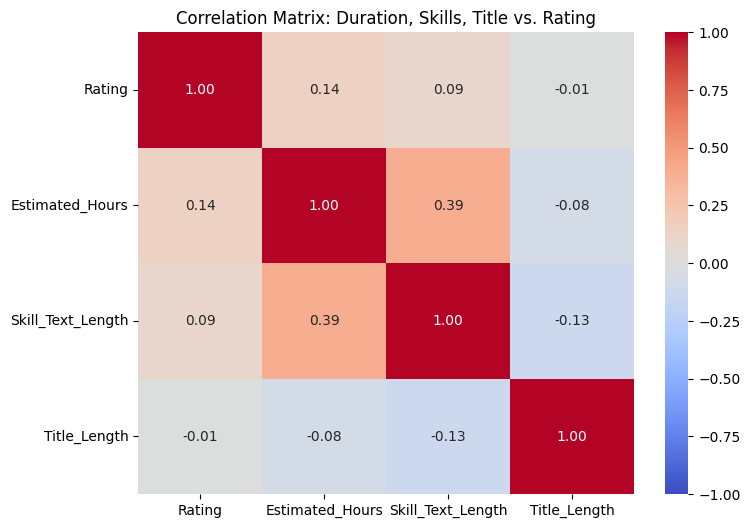

In [67]:
# --- 3. Correlation Matrix (Heatmap) ---
# Create a subset of numerical columns for correlation
corr_cols = ['Rating', 'Estimated_Hours', 'Skill_Text_Length', 'Title_Length']
corr_matrix = unified_online_course_df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix: Duration, Skills, Title vs. Rating')
plt.show()